# Nius
Load Nius CSV files and create a DataFrame named `df`.

In [212]:
from pathlib import Path
import pandas as pd

def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, cwd.parent):
        if (candidate / "data" / "raw" / "Alternative Medien").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing data/raw/Alternative Medien")

def read_csv_resilient(csv_path: Path) -> pd.DataFrame:
    for encoding in ("utf-8", "utf-8-sig", "latin-1"):
        try:
            return pd.read_csv(
                csv_path,
                encoding=encoding,
                low_memory=False,
                on_bad_lines="skip",
            )
        except Exception:
            pass

    for encoding in ("utf-8", "utf-8-sig", "latin-1"):
        try:
            return pd.read_csv(
                csv_path,
                encoding=encoding,
                sep=None,
                engine="python",
                low_memory=False,
                on_bad_lines="skip",
            )
        except Exception:
            pass

    raise ValueError(f"Could not read: {csv_path}")

PROJECT_ROOT = resolve_project_root()
BASE_DIR = PROJECT_ROOT / "data" / "raw" / "Alternative Medien"

SOURCE_NAME = "Nius"
source_dir_candidates = [BASE_DIR / SOURCE_NAME, BASE_DIR / f"{SOURCE_NAME}_Rohdaten_neu"]
SOURCE_DIR = BASE_DIR / SOURCE_NAME
csv_files = []
for candidate in source_dir_candidates:
    if candidate.exists():
        candidate_files = sorted(candidate.rglob("*.csv"))
        if candidate_files:
            SOURCE_DIR = candidate
            csv_files = candidate_files
            break
if not csv_files and SOURCE_DIR.exists():
    csv_files = sorted(SOURCE_DIR.rglob("*.csv"))

parts = []
for csv_file in csv_files:
    part = read_csv_resilient(csv_file)
    part["source"] = SOURCE_NAME
    part["source_file"] = csv_file.name
    parts.append(part)

df = pd.concat(parts, ignore_index=True, sort=False) if parts else pd.DataFrame()

print(f"Loaded {len(df)} rows from {len(csv_files)} file(s) in {SOURCE_DIR}")
pd.reset_option('display.max_colwidth')
df.head()


Loaded 4885 rows from 285 file(s) in /Users/MattisHaumann/Dev/Thesis/data/raw/Alternative Medien/Nius_Rohdaten_neu


,id,title,titleHtml,intro,articleRef,categoryRef,articleAltRef,images,tags,video,...,isPaidContent,isTopClickModule,topClickCustomContent,showSystemTeaserTitle,meta,url,day,article_text,source,source_file
0,0682defd-0f5f-4469-812b-20d7cca70273,Zitter-Wahl oder Durchmarsch: Wie sicher ist F...,<span>Zitter-Wahl oder Durchmarsch: Wie sicher...,NaN,/politik/news/zitter-wahl-oder-durchmarsch-wie...,/politik,/articles/zitter-wahl-oder-durchmarsch-wie-sic...,{'big_1x': 'https://api.nius.de/api/assets/off...,[],NaN,...,False,False,[],True,"{'title': ""Zitter-Wahl oder Durchmarsch: Wie s...",https://www.nius.de/politik/news/zitter-wahl-o...,2025-05-01,# Zitter-Wahl oder Durchmarsch: Wie sicher ist...,Nius,nius_2025-05-01.csv
1,53d0259d-761e-4377-84b8-12185aaf54e8,"Erst fällt die Brandmauer, dann fließen Tränen...","<span>Erst fällt die Brandmauer, dann fließen ...",NaN,/gesellschaft/news/brandmauer-wurzen-demokrati...,/gesellschaft,/articles/brandmauer-wurzen-demokratie-netzwer...,{'big_1x': 'https://api.nius.de/api/assets/off...,[],NaN,...,False,False,[],True,"{'title': 'Erst fällt die Brandmauer, dann fli...",https://www.nius.de/gesellschaft/news/brandmau...,2025-05-01,"# Erst fällt die Brandmauer, dann fließen Trän...",Nius,nius_2025-05-01.csv
2,4535cc72-254b-4fd5-a7b6-24a24de52784,"Als Merkel noch mal „Wir schaffen das“ sagt, b...",<span>Als Merkel noch mal „Wir schaffen das“ s...,NaN,/gesellschaft/news/angela-merkel-evangelischer...,/gesellschaft,/articles/angela-merkel-evangelischer-kirchent...,{'big_1x': 'https://api.nius.de/api/assets/off...,[],NaN,...,False,False,[],True,{'title': 'Als Merkel noch mal „Wir schaffen d...,https://www.nius.de/gesellschaft/news/angela-m...,2025-05-01,"# Als Merkel noch mal „Wir schaffen das“ sagt,...",Nius,nius_2025-05-01.csv
3,3c62c613-6cb8-49da-a8f6-c3727a9e55b6,Absage an Transideologie: Englischer Fußballve...,<span>Absage an Transideologie: Englischer Fuß...,NaN,/sport/news/absage-an-transideologie-englische...,/sport,/articles/absage-an-transideologie-englischer-...,{'big_1x': 'https://api.nius.de/api/assets/off...,[],NaN,...,False,False,[],True,{'title': 'Absage an Transideologie: Englische...,https://www.nius.de/sport/news/absage-an-trans...,2025-05-01,# Absage an Transideologie: Englischer Fußball...,Nius,nius_2025-05-01.csv
4,152af3f3-137d-4a51-8f8c-5bf8c5cdbe8b,Ex-Briten-Premier Tony Blair: Bisherige Klima...,<span>Ex-Briten-Premier Tony Blair: Bisherige...,NaN,/politik/news/ex-briten-premier-tony-blair-bis...,/politik,/articles/ex-briten-premier-tony-blair-bisheri...,{'big_1x': 'https://api.nius.de/api/assets/off...,[],NaN,...,False,False,[],True,{'title': 'Ex-Briten-Premier Tony Blair: Bish...,https://www.nius.de/politik/news/ex-briten-pre...,2025-05-01,# Ex-Briten-Premier Tony Blair: Bisherige Klim...,Nius,nius_2025-05-01.csv


In [213]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4885 entries, 0 to 4884
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     4885 non-null   str    
 1   title                  4885 non-null   str    
 2   titleHtml              4885 non-null   str    
 3   intro                  3 non-null      object 
 4   articleRef             4885 non-null   str    
 5   categoryRef            4885 non-null   str    
 6   articleAltRef          4885 non-null   str    
 7   images                 4885 non-null   str    
 8   tags                   4885 non-null   str    
 9   video                  0 non-null      float64
 10  categories             4885 non-null   str    
 11  slug                   4885 non-null   str    
 12  lastModified           4885 non-null   str    
 13  created                4885 non-null   str    
 14  publishedAt            4885 non-null   str    
 15  template       

## Data Cleaning

In [214]:
df_clean = df[['title', 'categories', 'day', 'authors', 'article_text', 'url']].copy()
df_clean.head()

,title,categories,day,authors,article_text,url
0,Zitter-Wahl oder Durchmarsch: Wie sicher ist F...,['Politik'],2025-05-01,"[{'id': '644a4264f03076c588c3da92', 'email': '...",# Zitter-Wahl oder Durchmarsch: Wie sicher ist...,https://www.nius.de/politik/news/zitter-wahl-o...
1,"Erst fällt die Brandmauer, dann fließen Tränen...",['Gesellschaft'],2025-05-01,"[{'id': '64ac16eb3450f0e44302535e', 'email': '...","# Erst fällt die Brandmauer, dann fließen Trän...",https://www.nius.de/gesellschaft/news/brandmau...
2,"Als Merkel noch mal „Wir schaffen das“ sagt, b...",['Gesellschaft'],2025-05-01,"[{'id': '644f639cf03076c588c404f5', 'email': '...","# Als Merkel noch mal „Wir schaffen das“ sagt,...",https://www.nius.de/gesellschaft/news/angela-m...
3,Absage an Transideologie: Englischer Fußballve...,['Sport'],2025-05-01,"[{'id': '644f639cf03076c588c404f5', 'email': '...",# Absage an Transideologie: Englischer Fußball...,https://www.nius.de/sport/news/absage-an-trans...
4,Ex-Briten-Premier Tony Blair: Bisherige Klima...,['Politik'],2025-05-01,"[{'id': '644a43e2f03076c588c3dad6', 'email': '...",# Ex-Briten-Premier Tony Blair: Bisherige Klim...,https://www.nius.de/politik/news/ex-briten-pre...


In [215]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 4885 entries, 0 to 4884
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   title         4885 non-null   str  
 1   categories    4885 non-null   str  
 2   day           4885 non-null   str  
 3   authors       4885 non-null   str  
 4   article_text  4872 non-null   str  
 5   url           4885 non-null   str  
dtypes: str(6)
memory usage: 229.1 KB


In [216]:
# If previously created duplicated uppercase columns, remove them first
cols_upper = ["Title", "Text", "Date", "Authors", "Categories", "URL"]
df_clean = df_clean.drop(columns=[c for c in cols_upper if c in df_clean.columns], errors="ignore")

# Rename existing columns instead of creating new ones
df_clean = df_clean.rename(columns={
    "title": "Title",
    "article_text": "Text",
    "day": "Date",
    "authors": "Authors",
    "categories": "Categories",
    "url": "URL",
})

# Type cleanup
df_clean["Title"] = df_clean["Title"].astype(str)
df_clean["Text"] = df_clean["Text"].astype(str)
df_clean["Date"] = pd.to_datetime(df_clean["Date"], errors="coerce")
df_clean["Authors"] = df_clean["Authors"].astype(str)
df_clean["Categories"] = df_clean["Categories"].astype(str)
df_clean["URL"] = df_clean["URL"].astype(str)

In [217]:
df_clean

,Title,Categories,Date,Authors,Text,URL
0,Zitter-Wahl oder Durchmarsch: Wie sicher ist F...,['Politik'],2025-05-01,"[{'id': '644a4264f03076c588c3da92', 'email': '...",# Zitter-Wahl oder Durchmarsch: Wie sicher ist...,https://www.nius.de/politik/news/zitter-wahl-o...
1,"Erst fällt die Brandmauer, dann fließen Tränen...",['Gesellschaft'],2025-05-01,"[{'id': '64ac16eb3450f0e44302535e', 'email': '...","# Erst fällt die Brandmauer, dann fließen Trän...",https://www.nius.de/gesellschaft/news/brandmau...
2,"Als Merkel noch mal „Wir schaffen das“ sagt, b...",['Gesellschaft'],2025-05-01,"[{'id': '644f639cf03076c588c404f5', 'email': '...","# Als Merkel noch mal „Wir schaffen das“ sagt,...",https://www.nius.de/gesellschaft/news/angela-m...
3,Absage an Transideologie: Englischer Fußballve...,['Sport'],2025-05-01,"[{'id': '644f639cf03076c588c404f5', 'email': '...",# Absage an Transideologie: Englischer Fußball...,https://www.nius.de/sport/news/absage-an-trans...
4,Ex-Briten-Premier Tony Blair: Bisherige Klima...,['Politik'],2025-05-01,"[{'id': '644a43e2f03076c588c3dad6', 'email': '...",# Ex-Briten-Premier Tony Blair: Bisherige Klim...,https://www.nius.de/politik/news/ex-briten-pre...
...,...,...,...,...,...,...
4880,Crews der Lufthansa gehen am Donnerstag in den...,['Wirtschaft'],2026-02-10,"[{'id': '644f639cf03076c588c404f5', 'email': '...",# Crews der Lufthansa gehen am Donnerstag in d...,https://www.nius.de/wirtschaft/news/crews-der-...
4881,Aus dem Ghetto in den Rap-Olymp: Wie Nicki Min...,['Gesellschaft'],2026-02-10,"[{'id': '695b9af7c942967b5c6b9f8f', 'email': '...",# Aus dem Ghetto in den Rap-Olymp: Wie Nicki M...,https://www.nius.de/gesellschaft/news/ikone-ni...
4882,Das war NIUS Live am Mittwoch: Jetzt wackelt T...,['NIUS Live'],2026-02-10,"[{'id': '644f639cf03076c588c404f5', 'email': '...",# Das war NIUS Live am Mittwoch: Jetzt wackelt...,https://www.nius.de/nius-live/news/nius-live-j...
4883,Lüge über Epstein-Insel: Jetzt wackelt Trumps ...,['Ausland'],2026-02-10,"[{'id': '6551f4bc3064a95275381727', 'email': '...",# Lüge über Epstein-Insel: Jetzt wackelt Trump...,https://www.nius.de/ausland/news/luege-ueber-e...


In [218]:
nan_counts = df_clean.isna().sum()
total_nans = int(nan_counts.sum())

print(f"Any NaNs in df: {total_nans > 0}")
print(f"Total NaN values: {total_nans}")

Any NaNs in df: True
Total NaN values: 13


In [219]:
# Clean the data by dropping rows with NaN values
df_clean = df_clean.dropna()
print(f"Rows after dropping NaNs: {len(df_clean)}")

Rows after dropping NaNs: 4872


Duplicates

In [220]:
# Find duplicates (mark all members of each duplicate group)
dup_title_mask = df_clean.duplicated(subset=["Title"], keep=False)
dup_text_mask = df_clean.duplicated(subset=["Text"], keep=False)
rows_to_drop_mask = dup_title_mask | dup_text_mask

print(f"Rows with duplicate titles: {dup_title_mask.sum()}")
print(f"Rows with duplicate text: {dup_text_mask.sum()}")
print(f"Total rows to drop (title OR text duplicates): {rows_to_drop_mask.sum()}")

# Drop all rows that have duplicate title or duplicate text
df_clean = df_clean.loc[~rows_to_drop_mask].copy()

print(f"Rows remaining after drop: {len(df_clean)}")


Rows with duplicate titles: 2
Rows with duplicate text: 2
Total rows to drop (title OR text duplicates): 4
Rows remaining after drop: 4868


Clean author name column

In [221]:
#Clean author name
import re

def extract_author_name(authors_str):
    """Extract author name(s) from the authors column."""
    if pd.isna(authors_str) or authors_str is None:
        return None
    
    # Convert to string if not already
    authors_str = str(authors_str)
    
    # Use regex to extract all 'name': 'value' patterns directly
    matches = re.findall(r"'name':\s*'([^']*)'", authors_str)
    if matches:
        return ', '.join(matches)
    
    # Try double quotes as well
    matches = re.findall(r'"name":\s*"([^"]*)"', authors_str)
    if matches:
        return ', '.join(matches)
    
    return None

# Apply to the dataframe
df_clean['Authors'] = df_clean['Authors'].apply(extract_author_name)
df_clean.head()
   

,Title,Categories,Date,Authors,Text,URL
0,Zitter-Wahl oder Durchmarsch: Wie sicher ist F...,['Politik'],2025-05-01,Ralf Schuler,# Zitter-Wahl oder Durchmarsch: Wie sicher ist...,https://www.nius.de/politik/news/zitter-wahl-o...
1,"Erst fällt die Brandmauer, dann fließen Tränen...",['Gesellschaft'],2025-05-01,Marc Sierzputowski,"# Erst fällt die Brandmauer, dann fließen Trän...",https://www.nius.de/gesellschaft/news/brandmau...
2,"Als Merkel noch mal „Wir schaffen das“ sagt, b...",['Gesellschaft'],2025-05-01,Redaktion,"# Als Merkel noch mal „Wir schaffen das“ sagt,...",https://www.nius.de/gesellschaft/news/angela-m...
3,Absage an Transideologie: Englischer Fußballve...,['Sport'],2025-05-01,Redaktion,# Absage an Transideologie: Englischer Fußball...,https://www.nius.de/sport/news/absage-an-trans...
4,Ex-Briten-Premier Tony Blair: Bisherige Klima...,['Politik'],2025-05-01,Julius Böhm,# Ex-Briten-Premier Tony Blair: Bisherige Klim...,https://www.nius.de/politik/news/ex-briten-pre...


In [222]:
#pd.set_option('display.max_colwidth', None)
df_clean.head(5)

,Title,Categories,Date,Authors,Text,URL
0,Zitter-Wahl oder Durchmarsch: Wie sicher ist F...,['Politik'],2025-05-01,Ralf Schuler,# Zitter-Wahl oder Durchmarsch: Wie sicher ist...,https://www.nius.de/politik/news/zitter-wahl-o...
1,"Erst fällt die Brandmauer, dann fließen Tränen...",['Gesellschaft'],2025-05-01,Marc Sierzputowski,"# Erst fällt die Brandmauer, dann fließen Trän...",https://www.nius.de/gesellschaft/news/brandmau...
2,"Als Merkel noch mal „Wir schaffen das“ sagt, b...",['Gesellschaft'],2025-05-01,Redaktion,"# Als Merkel noch mal „Wir schaffen das“ sagt,...",https://www.nius.de/gesellschaft/news/angela-m...
3,Absage an Transideologie: Englischer Fußballve...,['Sport'],2025-05-01,Redaktion,# Absage an Transideologie: Englischer Fußball...,https://www.nius.de/sport/news/absage-an-trans...
4,Ex-Briten-Premier Tony Blair: Bisherige Klima...,['Politik'],2025-05-01,Julius Böhm,# Ex-Briten-Premier Tony Blair: Bisherige Klim...,https://www.nius.de/politik/news/ex-briten-pre...


In [223]:
def remove_trailing_nius_reference(text):
    """Remove trailing 'Mehr NIUS:', 'Auch bei NIUS:', etc. from article text."""
    if pd.isna(text) or text is None:
        return text
    
    # Pattern to match trailing NIUS references at the end of the text
    # Matches variations like "Mehr NIUS:", "Mehr bei NIUS:", "Auch bei NIUS:", etc.
    # followed by any remaining text until the end
    pattern = r'\n*(?:Mehr|Auch|Lesen\s+[Ss]ie\s+auch)\s+(?:bei\s+)?NIUS\s*:.*$'
    
    cleaned = re.sub(pattern, '', str(text), flags=re.IGNORECASE | re.DOTALL)
    return cleaned.strip()

df_clean['Text'] = df_clean['Text'].apply(remove_trailing_nius_reference)
df_clean.head(10)

,Title,Categories,Date,Authors,Text,URL
0,Zitter-Wahl oder Durchmarsch: Wie sicher ist F...,['Politik'],2025-05-01,Ralf Schuler,# Zitter-Wahl oder Durchmarsch: Wie sicher ist...,https://www.nius.de/politik/news/zitter-wahl-o...
1,"Erst fällt die Brandmauer, dann fließen Tränen...",['Gesellschaft'],2025-05-01,Marc Sierzputowski,"# Erst fällt die Brandmauer, dann fließen Trän...",https://www.nius.de/gesellschaft/news/brandmau...
2,"Als Merkel noch mal „Wir schaffen das“ sagt, b...",['Gesellschaft'],2025-05-01,Redaktion,"# Als Merkel noch mal „Wir schaffen das“ sagt,...",https://www.nius.de/gesellschaft/news/angela-m...
3,Absage an Transideologie: Englischer Fußballve...,['Sport'],2025-05-01,Redaktion,# Absage an Transideologie: Englischer Fußball...,https://www.nius.de/sport/news/absage-an-trans...
4,Ex-Briten-Premier Tony Blair: Bisherige Klima...,['Politik'],2025-05-01,Julius Böhm,# Ex-Briten-Premier Tony Blair: Bisherige Klim...,https://www.nius.de/politik/news/ex-briten-pre...
5,„Wir neigen zu fürchterlicher Herablassung“: H...,"['Schuler! Fragen, was ist']",2025-05-01,Ralf Schuler,# „Wir neigen zu fürchterlicher Herablassung“:...,"https://www.nius.de/schuler!-fragen,-was-ist/n..."
6,US-Außenminister Marco Rubio folgt auf gefeuer...,['Ausland'],2025-05-01,Redaktion,# US-Außenminister Marco Rubio folgt auf gefeu...,https://www.nius.de/ausland/news/us-aussenmini...
7,Schüsse und Stiche während 1. Mai-Demo: Zwei S...,['Kriminalität'],2025-05-01,Redaktion,# Schüsse und Stiche während 1. Mai-Demo: Zwei...,https://www.nius.de/kriminalitaet/news/berlin-...
8,Verurteilter IS-Unterstützer aus Syrien verlan...,['Kriminalität'],2025-05-02,Redaktion,# Verurteilter IS-Unterstützer aus Syrien verl...,https://www.nius.de/kriminalitaet/news/tischen...
9,Die linke Kaderschmiede im Innenministerium: W...,['Politik'],2025-05-02,Björn Harms,# Die linke Kaderschmiede im Innenministerium:...,https://www.nius.de/politik/news/bundeszentral...


In [224]:
# Remove newline characters from article_text
df_clean['Text'] = df_clean['Text'].str.replace('\n', ' ', regex=False)
df_clean.head()

,Title,Categories,Date,Authors,Text,URL
0,Zitter-Wahl oder Durchmarsch: Wie sicher ist F...,['Politik'],2025-05-01,Ralf Schuler,# Zitter-Wahl oder Durchmarsch: Wie sicher ist...,https://www.nius.de/politik/news/zitter-wahl-o...
1,"Erst fällt die Brandmauer, dann fließen Tränen...",['Gesellschaft'],2025-05-01,Marc Sierzputowski,"# Erst fällt die Brandmauer, dann fließen Trän...",https://www.nius.de/gesellschaft/news/brandmau...
2,"Als Merkel noch mal „Wir schaffen das“ sagt, b...",['Gesellschaft'],2025-05-01,Redaktion,"# Als Merkel noch mal „Wir schaffen das“ sagt,...",https://www.nius.de/gesellschaft/news/angela-m...
3,Absage an Transideologie: Englischer Fußballve...,['Sport'],2025-05-01,Redaktion,# Absage an Transideologie: Englischer Fußball...,https://www.nius.de/sport/news/absage-an-trans...
4,Ex-Briten-Premier Tony Blair: Bisherige Klima...,['Politik'],2025-05-01,Julius Böhm,# Ex-Briten-Premier Tony Blair: Bisherige Klim...,https://www.nius.de/politik/news/ex-briten-pre...


Filter period

In [225]:
# Extract relevant time period
# Convert 'Date' column to datetime 
df_clean['Date'] = pd.to_datetime(df_clean['Date'])

# Filter for articles from August 2025 to January 2026
start_date = '2025-08-01'
end_date = '2026-01-31'

df_clean = df_clean[(df_clean['Date'] >= start_date) & (df_clean['Date'] <= end_date)]
print(f"Rows after filtering to {start_date} - {end_date}: {len(df_clean)}")
df_clean.head()

Rows after filtering to 2025-08-01 - 2026-01-31: 3271


,Title,Categories,Date,Authors,Text,URL
1424,Das Bürgergeld-Leben der afghanischen Familie B.,['Gesellschaft'],2025-08-01,"Jan A. Karon, Björn Harms",# Das Bürgergeld-Leben der afghanischen Famili...,https://www.nius.de/gesellschaft/news/buergerg...
1425,Die Planwirtschaft von Ursula von der Leyen ha...,['Politik'],2025-08-01,Kurt Lauk,# Die Planwirtschaft von Ursula von der Leyen ...,https://www.nius.de/politik/news/die-planwirts...
1426,Jeder vierte Ausländer (20-25) geht nicht zu S...,['Gesellschaft'],2025-08-01,Redaktion,# Jeder vierte Ausländer (20-25) geht nicht zu...,https://www.nius.de/gesellschaft/news/jeder-vi...
1427,Polizei schickt Deutschen Schäferhund in Rente,['Kommentar'],2025-08-01,Louis Hagen,# Polizei schickt Deutschen Schäferhund in Ren...,https://www.nius.de/kommentar/news/polizei-sch...
1428,Kosovo-Clan schlägt Frau auf offener Straße zu...,['Kriminalität'],2025-08-01,Helena Gebhard,# Kosovo-Clan schlägt Frau auf offener Straße ...,https://www.nius.de/kriminalitaet/news/kosovo-...


In [226]:
df_clean['Date'].min(), df_clean['Date'].max()

(Timestamp('2025-08-01 00:00:00'), Timestamp('2026-01-31 00:00:00'))

Filter unmeaningful categories

In [227]:
df_clean['Categories'].value_counts()

Categories
['Politik']                     861
['Kommentar']                   295
['Wirtschaft']                  263
['Kriminalität']                248
['Gesellschaft']                243
['Ausland']                     241
['Nachrichten']                 237
['NIUS Live']                   223
['Analyse']                     176
['Medien']                      159
['Kissler Kompakt']              83
['Unterhaltung']                 63
['Schuler! Fragen, was ist']     46
['Statistik']                    28
['Gio unzensiert']               19
['Interview']                    15
['Sport']                        13
[]                               13
['Berlin']                       13
['Nius Originals']               13
['Energie']                      11
['Corona']                        4
['Achtung, Reichelt!']            2
['Show']                          2
Name: count, dtype: int64

In [228]:
# Filter for rows with empty categories
empty_categories = df_clean[df_clean['Categories'] == '[]']
print(f"Number of articles with empty categories: {len(empty_categories)}")
print(f"\nPercentage of total: {len(empty_categories) / len(df_clean) * 100:.2f}%")
print(f"\nSample of articles with empty categories:")
empty_categories[['Title', 'Categories', 'Date', 'Authors','Text']].head(10)

Number of articles with empty categories: 13

Percentage of total: 0.40%

Sample of articles with empty categories:


,Title,Categories,Date,Authors,Text
1554,Trump und Putin treffen sich am Freitag in Alaska,[],2025-08-09,Redaktion,# Trump und Putin treffen sich am Freitag in A...
1896,Exklusives Gewinnspiel bei NIUS,[],2025-09-01,Redaktion,# Exklusives Gewinnspiel bei NIUS Willkommen ...
3198,Gewalt an Schulen geht durch die Decke - vor a...,[],2025-11-09,Redaktion,# Gewalt an Schulen geht durch die Decke - vor...
3209,Mann nach Festnahme wieder auf freiem Fuß: 17-...,[],2025-11-10,Redaktion,# Mann nach Festnahme wieder auf freiem Fuß: 1...
3264,Das war NIUS Live am Abend: Rentenstreit eskal...,[],2025-11-11,Redaktion,# Das war NIUS Live am Abend: Rentenstreit esk...
3631,Gründungsparteitag der AfD-Jugend in Gießen: D...,[],2025-11-28,"Jan A. Karon, Björn Harms",# Gründungsparteitag der AfD-Jugend in Gießen:...
3746,Neue Studie: Rechtsextremismus besorgt Deutsch...,[],2025-12-07,Redaktion,# Neue Studie: Rechtsextremismus besorgt Deuts...
4051,Siemens-Bahnchef Michael Peter: Von Berlin nac...,[],2025-12-23,Redaktion,# Siemens-Bahnchef Michael Peter: Von Berlin n...
4056,„Erlauben Sie ihnen die Einreise nach Deutschl...,[],2025-12-23,Redaktion,# „Erlauben Sie ihnen die Einreise nach Deutsc...
4064,Selenskyj legt 20-Punkte-Entwurf für möglichen...,[],2025-12-24,Redaktion,# Selenskyj legt 20-Punkte-Entwurf für möglich...


In [229]:
# Filter for rows with Show categories
show_categories = df_clean[df_clean['Categories'].str.contains('Show', na=False)]
print(f"Number of articles with 'Show' category: {len(show_categories)}")
print(f"\nPercentage of total: {len(show_categories) / len(df_clean) * 100:.2f}%")
print(f"\nSample of articles with 'Show' category:")
show_categories[['Title', 'Categories', 'Date', 'Authors', 'Text']].head(10)

Number of articles with 'Show' category: 2

Percentage of total: 0.06%

Sample of articles with 'Show' category:


,Title,Categories,Date,Authors,Text
3346,Exklusiv: Frag Pauline Voss Live am Montag,['Show'],2025-11-14,"Helena Gebhard, Pauline Voss",# Exklusiv: Frag Pauline Voss Live am Montag ...
4685,Exklusiv: Grill den Reichelt Live am Donnerstag!,['Show'],2026-01-30,Redaktion,# Exklusiv: Grill den Reichelt Live am Donners...


Category 'Show' seems to be advertisement, therefore deleted from dataset

In [230]:
# Drop rows where categories contains 'Show'
df_clean = df_clean[~df_clean['Categories'].str.contains('Show', na=False)]
print(f"Rows after dropping 'Show' category: {len(df_clean)}")

Rows after dropping 'Show' category: 3269


In [231]:
nius_clean = df_clean.copy()
nius_clean['source'] = 'Nius'

nius_clean = nius_clean[['Date', 'Title', 'Text', 'source']].copy()
nius_clean.to_csv("nius_clean.csv", index=False, encoding="utf-8")

## EDA

In [232]:
# Create a table showing number of articles per month
articles_per_month = df_clean.groupby(df_clean['Date'].dt.to_period('M')).size().reset_index(name='article_count')
articles_per_month.columns = ['month', 'article_count']
articles_per_month

,month,article_count
0,2025-08,465
1,2025-09,563
2,2025-10,585
3,2025-11,601
4,2025-12,508
5,2026-01,547


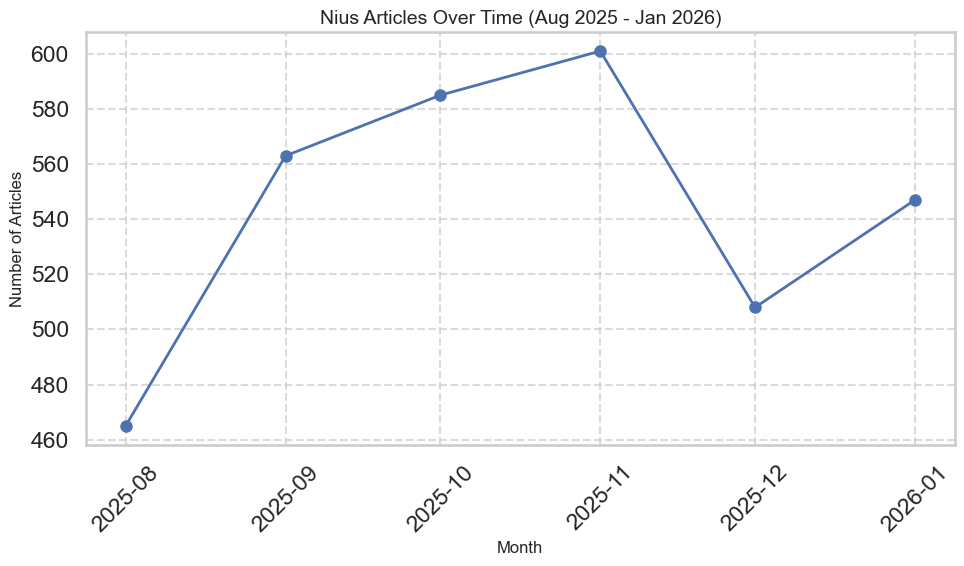

In [233]:
import matplotlib.pyplot as plt

# Create a time series plot of articles per month
fig, ax = plt.subplots(figsize=(10, 6))

# Convert period to timestamp for plotting
articles_per_month['month_ts'] = articles_per_month['month'].dt.to_timestamp()

ax.plot(articles_per_month['month_ts'], articles_per_month['article_count'], marker='o', linewidth=2, markersize=8)

ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Number of Articles', fontsize=12)
ax.set_title('Nius Articles Over Time (Aug 2025 - Jan 2026)', fontsize=14)

plt.xticks(rotation=45)
ax.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [234]:
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)

eda_df = df_clean.copy()
eda_df["Date"] = pd.to_datetime(eda_df["Date"], errors="coerce")

eda_df["Text"] = eda_df["Text"].astype("string")
eda_df = eda_df.dropna(subset=["Date", "Text"]).copy()

print(f"Rows used for EDA: {len(eda_df):,}")

Rows used for EDA: 3,269


In [235]:
eda_df["article_length_words"] = eda_df["Text"].str.split().str.len()
eda_df["article_length_chars"] = eda_df["Text"].str.len()

eda_df["article_length_words"].describe(
    percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
).round(1)

count    3269.0
mean      560.7
std       508.0
min         4.0
10%       139.0
25%       241.0
50%       418.0
75%       680.0
90%      1168.2
95%      1596.2
99%      2439.2
max      5932.0
Name: article_length_words, dtype: float64

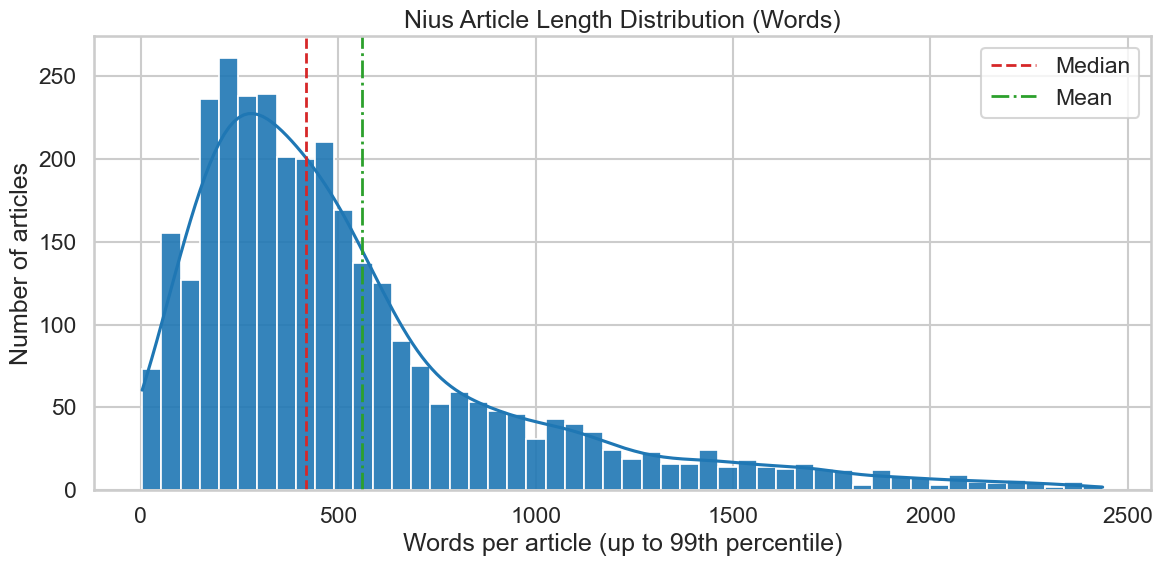

In [236]:
q99 = eda_df["article_length_words"].quantile(0.99)
length_plot = eda_df[eda_df["article_length_words"] <= q99]

fig, ax = plt.subplots(figsize=(12, 6))
sns.histplot(
    length_plot["article_length_words"],
    bins=50,
    kde=True,
    color="#1f77b4",
    edgecolor="white",
    alpha=0.9,
    ax=ax,
)

ax.axvline(eda_df["article_length_words"].median(), color="#d62728", linestyle="--", linewidth=2, label="Median")
ax.axvline(eda_df["article_length_words"].mean(), color="#2ca02c", linestyle="-.", linewidth=2, label="Mean")
ax.set_title("Nius Article Length Distribution (Words)")
ax.set_xlabel("Words per article (up to 99th percentile)")
ax.set_ylabel("Number of articles")
ax.legend()
plt.tight_layout()
plt.show()

## BERTopic

In [237]:
from pathlib import Path
import sys

def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, *cwd.parents):
        if (candidate / "1a_BERTopic").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing 1a_BERTopic")

project_root = resolve_project_root()
module_root = project_root / "1a_BERTopic"

if str(module_root) not in sys.path:
    sys.path.insert(0, str(module_root))


In [238]:
from bertopic_pipeline import run_bertopic_pipeline

In [239]:
from bertopic_config import BERTopicConfig
print(BERTopicConfig().min_df, BERTopicConfig().max_df)

2 0.9


In [240]:
from pathlib import Path
import sys

def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, *cwd.parents):
        if (candidate / "1a_BERTopic").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing 1a_BERTopic")

PROJECT_ROOT = resolve_project_root()
MODULE_ROOT = PROJECT_ROOT / "1a_BERTopic"
if str(MODULE_ROOT) not in sys.path:
    sys.path.insert(0, str(MODULE_ROOT))

print("cwd:", Path.cwd())
print("project root added:", PROJECT_ROOT)
print("bertopic module root added:", MODULE_ROOT)

cwd: /Users/MattisHaumann/Dev/Thesis/00_Initial EDA
project root added: /Users/MattisHaumann/Dev/Thesis
bertopic module root added: /Users/MattisHaumann/Dev/Thesis/1a_BERTopic


In [241]:
from pathlib import Path
import sys
import pandas as pd


def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / ".git").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing .git")


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CANONICAL_COMBINED_PATH = PROJECT_ROOT / "00_Initial EDA" / "df_combined.csv"
df_combined = pd.read_csv(CANONICAL_COMBINED_PATH)
df_clean = (
    df_combined.loc[df_combined["source"].eq("Nius")]
    .copy()
    .reset_index(drop=True)
)
print(f"Loaded canonical Nius subset from df_combined: {len(df_clean):,} rows")


Loaded canonical Nius subset from df_combined: 3,269 rows


In [242]:
# Legacy baseline run kept for reference only.
# Disabled on purpose so the notebook has one canonical Nius fit below.
# The final saved model keeps the full-text setup but adds English stopwords,
# `hdbscan_min_cluster_size=15`, and `top_n_words=30`.
# result_full_text = run_bertopic_pipeline(
#     df=df_clean,
#     text_col="Text",
#     config=BERTopicConfig(),
#     id_col="row_id",
#     source_name="Nius",
# )
# result_ns = result_full_text


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-31 21:45:01,247 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/103 [00:00<?, ?it/s]

2026-03-31 21:45:22,596 - BERTopic - Embedding - Completed ✓
2026-03-31 21:45:22,597 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-31 21:45:31,587 - BERTopic - Dimensionality - Completed ✓
2026-03-31 21:45:31,589 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-31 21:45:31,675 - BERTopic - Cluster - Completed ✓
2026-03-31 21:45:31,680 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-31 21:45:33,548 - BERTopic - Representation - Completed ✓


In [ ]:
print("Legacy Nius preview disabled. Use the canonical `result_nius` preview cells below.")


In [244]:
# Canonical final Nius run.
# After a default baseline pass, we kept the full-text setup and only tuned
# the Nius-specific cleanup via extra English stopwords plus
# `hdbscan_min_cluster_size=15` and `top_n_words=30`.
# English stopwords were added to fix HateAid articles leaking English terms into c-TF-IDF labels.
nius_extra_stopwords = (
    # English stopwords (HateAid and other bilingual content)
    "the", "of", "to", "and", "is", "in", "it", "for", "that", "with",
    "this", "on", "are", "as", "at", "be", "by", "from", "or", "an",
)

result_full_text = run_bertopic_pipeline(
    df=df_clean,
    text_col="Text",
    config=BERTopicConfig(
        hdbscan_min_cluster_size=15,
        top_n_words=30,
        extra_stopwords=nius_extra_stopwords,
    ),
    id_col="row_id",
    source_name="Nius",
)

# Keep downstream notebook cells unchanged (they use `result_nius`)
result_nius = result_full_text
result_ns = result_nius


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-31 21:45:41,866 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/103 [00:00<?, ?it/s]

2026-03-31 21:45:57,074 - BERTopic - Embedding - Completed ✓
2026-03-31 21:45:57,074 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-31 21:46:05,251 - BERTopic - Dimensionality - Completed ✓
2026-03-31 21:46:05,251 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-31 21:46:05,291 - BERTopic - Cluster - Completed ✓
2026-03-31 21:46:05,293 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-31 21:46:06,913 - BERTopic - Representation - Completed ✓


In [245]:
topic_info = result_nius["topic_info"]
topic_info.head(40)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,1123,-1_afd_merz_eu_union,"[afd, merz, eu, union, friedrich, linke, trump...",[# Wie die SPD die AfD verbieten will: Zwei vo...
1,0,261,0_polizei_mann_jährige_täter,"[polizei, mann, jährige, täter, tat, jährigen,...",[# Iraker wirft 16-Jährige vor den Zug: Das Pr...
2,1,194,1_moderator_studio_radio_abend,"[moderator, studio, radio, abend, geht direkt,...",[# Das war NIUS Live am Abend: DAX-Konzerne se...
3,2,143,2_migranten_migration_2015_ausländer,"[migranten, migration, 2015, ausländer, bürger...",[# Über 370.000 Migranten aus Nicht-EU-Ländern...
4,3,121,3_co2_eu_unternehmen_industrie,"[co2, eu, unternehmen, industrie, milliarden, ...","[# Politisch gewollt, ökonomisch verheerend: W..."
5,4,84,4_merz_friedrich_friedrich merz_kanzler,"[merz, friedrich, friedrich merz, kanzler, bun...",[# Enthüllt! Merz-Haushalt ist verfassungswidr...
6,5,81,5_kirk_charlie_charlie kirk_kirks,"[kirk, charlie, charlie kirk, kirks, robinson,...","[# Krieg gegen Konservative – Ruhe in Frieden,..."
7,6,80,6_hamas_israel_gaza_geiseln,"[hamas, israel, gaza, geiseln, gazastreifen, i...",[# Entwaffnung unabdingbar für Phase 2 des Gaz...
8,7,79,7_bürgergeld_union_bas_csu,"[bürgergeld, union, bas, csu, merz, koalition,...",[# Brisantes Bas-Dokument enthüllt: SPD will 2...
9,8,70,8_ukraine_putin_russland_trump,"[ukraine, putin, russland, trump, selenskyj, t...",[# Ukraine-Verhandlungen: Wie Putin mit dem Pr...


### Outlier Reduction (focused section)

This section starts from the already fitted Nius topic model (`result_nius`) and keeps the reduction workflow compact.

> **Final downstream workflow:** use the canonical final Nius fit above, then apply `reduce_outliers(..., strategy="c-tf-idf", threshold=0.10)`.


In [246]:
import pandas as pd
from copy import deepcopy

# Keep aligned with the exact reduced-model baseline selected above (result_nius).
base_result = result_nius
topic_model_base = base_result["topic_model"]
docs_ns = list(base_result["docs"])
topics_ns = list(base_result["topics"])
prepared_docs = base_result["prepared_documents"].copy()
baseline_topic_ids = {topic for topic in topics_ns if topic != -1}

new_topics_ctfidf_threshold = topic_model_base.reduce_outliers(
    docs_ns,
    topics_ns,
    strategy="c-tf-idf",
    threshold=0.10,
)
new_topics_ctfidf_threshold = list(new_topics_ctfidf_threshold)

redistributed_topic_ids = {topic for topic in new_topics_ctfidf_threshold if topic != -1}
unexpected_topic_ids = sorted(redistributed_topic_ids - baseline_topic_ids)
if unexpected_topic_ids:
    raise ValueError(
        f"Outlier reduction introduced new topic ids: {unexpected_topic_ids}. "
        "This notebook should only redistribute -1 documents into existing topics."
    )

topic_model_ctfidf_threshold = deepcopy(topic_model_base)
vectorizer_same = deepcopy(topic_model_base.vectorizer_model)
ctfidf_same = deepcopy(topic_model_base.ctfidf_model)
representation_same = deepcopy(topic_model_base.representation_model)

topic_model_ctfidf_threshold.update_topics(
    docs_ns,
    topics=new_topics_ctfidf_threshold,
    vectorizer_model=vectorizer_same,
    ctfidf_model=ctfidf_same,
    representation_model=representation_same,
    top_n_words=30,
)
topic_model_ctfidf_threshold.topics_ = list(new_topics_ctfidf_threshold)

topic_info_ctfidf_threshold = topic_model_ctfidf_threshold.get_topic_info().copy()
topic_info_ctfidf_threshold["OriginalTopic"] = topic_info_ctfidf_threshold["Topic"]
topic_info_ctfidf_threshold["TopicNameClean"] = topic_info_ctfidf_threshold["Name"].str.replace(r"^\d+_", "", regex=True)

ranked_topics = (
    topic_info_ctfidf_threshold.loc[topic_info_ctfidf_threshold["Topic"] != -1, ["Topic", "Count"]]
    .sort_values(["Count", "Topic"], ascending=[False, True])
    .reset_index(drop=True)
)
ranked_topics["DisplayTopic"] = range(1, len(ranked_topics) + 1)
display_topic_map = dict(zip(ranked_topics["Topic"], ranked_topics["DisplayTopic"]))

topic_info_ctfidf_threshold["DisplayTopic"] = (
    topic_info_ctfidf_threshold["Topic"].map(display_topic_map).astype("Int64")
)
topic_info_ctfidf_threshold["DisplayLabel"] = topic_info_ctfidf_threshold.apply(
    lambda row: "Outliers"
    if row["Topic"] == -1
    else f"Topic {int(row['DisplayTopic'])} — {row['TopicNameClean']}",
    axis=1,
)

ordered_cols = ["OriginalTopic", "DisplayTopic", "DisplayLabel", "TopicNameClean"]
remaining_cols = [col for col in topic_info_ctfidf_threshold.columns if col not in ordered_cols]
topic_info_ctfidf_threshold = topic_info_ctfidf_threshold[ordered_cols + remaining_cols]

topic_name_map_reduced = dict(zip(topic_info_ctfidf_threshold["Topic"], topic_info_ctfidf_threshold["Name"]))
display_label_map = dict(zip(topic_info_ctfidf_threshold["Topic"], topic_info_ctfidf_threshold["DisplayLabel"]))

doc_info_reduced = base_result["doc_info"].copy()
doc_info_reduced["Topic"] = list(new_topics_ctfidf_threshold)
if "Name" in doc_info_reduced.columns:
    doc_info_reduced["Name"] = doc_info_reduced["Topic"].map(topic_name_map_reduced)
doc_info_reduced["DisplayTopic"] = doc_info_reduced["Topic"].map(display_topic_map).astype("Int64")
doc_info_reduced["DisplayLabel"] = doc_info_reduced["Topic"].map(display_label_map)

result_nius_reduced = dict(base_result)
result_nius_reduced["topics"] = list(new_topics_ctfidf_threshold)
result_nius_reduced["topic_model"] = topic_model_ctfidf_threshold
result_nius_reduced["topic_info"] = topic_info_ctfidf_threshold
result_nius_reduced["topic_info_display"] = topic_info_ctfidf_threshold.copy()
result_nius_reduced["doc_info"] = doc_info_reduced
result_nius_reduced["display_topic_map"] = display_topic_map
result_nius_reduced["display_label_map"] = display_label_map

summary_final = pd.DataFrame([
    {
        "Variant": "baseline",
        "Outlier_Count": int((pd.Series(topics_ns) == -1).sum()),
        "Non_Outlier_Topic_Count": len(baseline_topic_ids),
    },
    {
        "Variant": "ctfidf_threshold_0.10",
        "Outlier_Count": int((pd.Series(new_topics_ctfidf_threshold) == -1).sum()),
        "Non_Outlier_Topic_Count": len(redistributed_topic_ids),
    },
])
display(summary_final)
display(topic_info_ctfidf_threshold.head(20))


2026-03-31 21:46:08,941 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


,Variant,Outlier_Count,Non_Outlier_Topic_Count
0,baseline,1123,38
1,ctfidf_threshold_0.10,493,38


,OriginalTopic,DisplayTopic,DisplayLabel,TopicNameClean,Topic,Count,Name,Representation,Representative_Docs
0,-1,<NA>,Outliers,-1_corona_mich_mir_angst,-1,493,-1_corona_mich_mir_angst,"[corona, mich, mir, angst, eltern, nie, millio...",[# Wie die SPD die AfD verbieten will: Zwei vo...
1,0,1,Topic 1 — jährige_täter_tat_jährigen,jährige_täter_tat_jährigen,0,310,0_jährige_täter_tat_jährigen,"[jährige, täter, tat, jährigen, verletzt, mess...",[# Iraker wirft 16-Jährige vor den Zug: Das Pr...
2,1,2,Topic 2 — moderator_studio_radio_abend,moderator_studio_radio_abend,1,195,1_moderator_studio_radio_abend,"[moderator, studio, radio, abend, geht direkt,...",[# Das war NIUS Live am Abend: DAX-Konzerne se...
3,2,3,Topic 3 — migranten_ausländer_2015_bürgergeld,migranten_ausländer_2015_bürgergeld,2,168,2_migranten_ausländer_2015_bürgergeld,"[migranten, ausländer, 2015, bürgergeld, flüch...",[# Über 370.000 Migranten aus Nicht-EU-Ländern...
4,3,5,Topic 5 — co2_industrie_milliarden_energiewende,co2_industrie_milliarden_energiewende,3,141,3_co2_industrie_milliarden_energiewende,"[co2, industrie, milliarden, energiewende, wir...","[# Politisch gewollt, ökonomisch verheerend: W..."
5,4,4,Topic 4 — friedrich merz_kanzler_bundeskanzler...,friedrich merz_kanzler_bundeskanzler_union,4,165,4_friedrich merz_kanzler_bundeskanzler_union,"[friedrich merz, kanzler, bundeskanzler, union...",[# Enthüllt! Merz-Haushalt ist verfassungswidr...
6,5,9,Topic 9 — kirk_charlie_charlie kirk_kirks,kirk_charlie_charlie kirk_kirks,5,92,5_kirk_charlie_charlie kirk_kirks,"[kirk, charlie, charlie kirk, kirks, robinson,...","[# Krieg gegen Konservative – Ruhe in Frieden,..."
7,6,7,Topic 7 — hamas_israel_gaza_geiseln,hamas_israel_gaza_geiseln,6,93,6_hamas_israel_gaza_geiseln,"[hamas, israel, gaza, geiseln, gazastreifen, i...",[# Entwaffnung unabdingbar für Phase 2 des Gaz...
8,7,6,Topic 6 — bas_bürgergeld_union_bärbel bas,bas_bürgergeld_union_bärbel bas,7,109,7_bas_bürgergeld_union_bärbel bas,"[bas, bürgergeld, union, bärbel bas, bärbel, c...",[# Brisantes Bas-Dokument enthüllt: SPD will 2...
9,8,14,Topic 14 — ukraine_putin_russland_selenskyj,ukraine_putin_russland_selenskyj,8,87,8_ukraine_putin_russland_selenskyj,"[ukraine, putin, russland, selenskyj, trump, p...",[# Ukraine-Verhandlungen: Wie Putin mit dem Pr...


### Save final reduced model (`ns_model` overwrite)

Persist the final threshold-based reduced model so this is the canonical saved Nius model in `1a_BERTopic/outputs/ns_model` for downstream loading and merged-model use.


In [247]:
from pathlib import Path
import shutil

# Keep a reusable reduced result dict in notebook memory and save the canonical final Nius model to outputs/.
result_nius = result_nius_reduced
topic_info = result_nius["topic_info"]

def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / ".git").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing .git")

project_root = find_project_root(Path.cwd())

SAVE_DIRS = [
    project_root / "1a_BERTopic" / "outputs" / "ns_model",
]

for save_dir in SAVE_DIRS:
    save_dir.parent.mkdir(parents=True, exist_ok=True)
    if save_dir.exists():
        shutil.rmtree(save_dir)
    topic_model_ctfidf_threshold.save(
        save_dir,
        serialization="safetensors",
        save_ctfidf=True,
        save_embedding_model="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
    )
    print(f"Saved final reduced model to: {save_dir}")


Saved final reduced model to: /Users/MattisHaumann/Dev/Thesis/1a_BERTopic/outputs/ns_model


In [248]:
# Unified display numbering for the final reduced model (largest topic = Topic 1).
topic_display_result = result_nius_reduced if "result_nius_reduced" in globals() else result_nius
topic_info = topic_display_result["topic_info"].copy()
display_topic_map = topic_display_result["display_topic_map"]
display_label_map = topic_display_result["display_label_map"]

display(topic_info.head(20))


,OriginalTopic,DisplayTopic,DisplayLabel,TopicNameClean,Topic,Count,Name,Representation,Representative_Docs
0,-1,<NA>,Outliers,-1_corona_mich_mir_angst,-1,493,-1_corona_mich_mir_angst,"[corona, mich, mir, angst, eltern, nie, millio...",[# Wie die SPD die AfD verbieten will: Zwei vo...
1,0,1,Topic 1 — jährige_täter_tat_jährigen,jährige_täter_tat_jährigen,0,310,0_jährige_täter_tat_jährigen,"[jährige, täter, tat, jährigen, verletzt, mess...",[# Iraker wirft 16-Jährige vor den Zug: Das Pr...
2,1,2,Topic 2 — moderator_studio_radio_abend,moderator_studio_radio_abend,1,195,1_moderator_studio_radio_abend,"[moderator, studio, radio, abend, geht direkt,...",[# Das war NIUS Live am Abend: DAX-Konzerne se...
3,2,3,Topic 3 — migranten_ausländer_2015_bürgergeld,migranten_ausländer_2015_bürgergeld,2,168,2_migranten_ausländer_2015_bürgergeld,"[migranten, ausländer, 2015, bürgergeld, flüch...",[# Über 370.000 Migranten aus Nicht-EU-Ländern...
4,3,5,Topic 5 — co2_industrie_milliarden_energiewende,co2_industrie_milliarden_energiewende,3,141,3_co2_industrie_milliarden_energiewende,"[co2, industrie, milliarden, energiewende, wir...","[# Politisch gewollt, ökonomisch verheerend: W..."
5,4,4,Topic 4 — friedrich merz_kanzler_bundeskanzler...,friedrich merz_kanzler_bundeskanzler_union,4,165,4_friedrich merz_kanzler_bundeskanzler_union,"[friedrich merz, kanzler, bundeskanzler, union...",[# Enthüllt! Merz-Haushalt ist verfassungswidr...
6,5,9,Topic 9 — kirk_charlie_charlie kirk_kirks,kirk_charlie_charlie kirk_kirks,5,92,5_kirk_charlie_charlie kirk_kirks,"[kirk, charlie, charlie kirk, kirks, robinson,...","[# Krieg gegen Konservative – Ruhe in Frieden,..."
7,6,7,Topic 7 — hamas_israel_gaza_geiseln,hamas_israel_gaza_geiseln,6,93,6_hamas_israel_gaza_geiseln,"[hamas, israel, gaza, geiseln, gazastreifen, i...",[# Entwaffnung unabdingbar für Phase 2 des Gaz...
8,7,6,Topic 6 — bas_bürgergeld_union_bärbel bas,bas_bürgergeld_union_bärbel bas,7,109,7_bas_bürgergeld_union_bärbel bas,"[bas, bürgergeld, union, bärbel bas, bärbel, c...",[# Brisantes Bas-Dokument enthüllt: SPD will 2...
9,8,14,Topic 14 — ukraine_putin_russland_selenskyj,ukraine_putin_russland_selenskyj,8,87,8_ukraine_putin_russland_selenskyj,"[ukraine, putin, russland, selenskyj, trump, p...",[# Ukraine-Verhandlungen: Wie Putin mit dem Pr...


### UMAP topic map (reduced model, no re-fit)

Visualize the final reduced topics from the threshold workflow above.


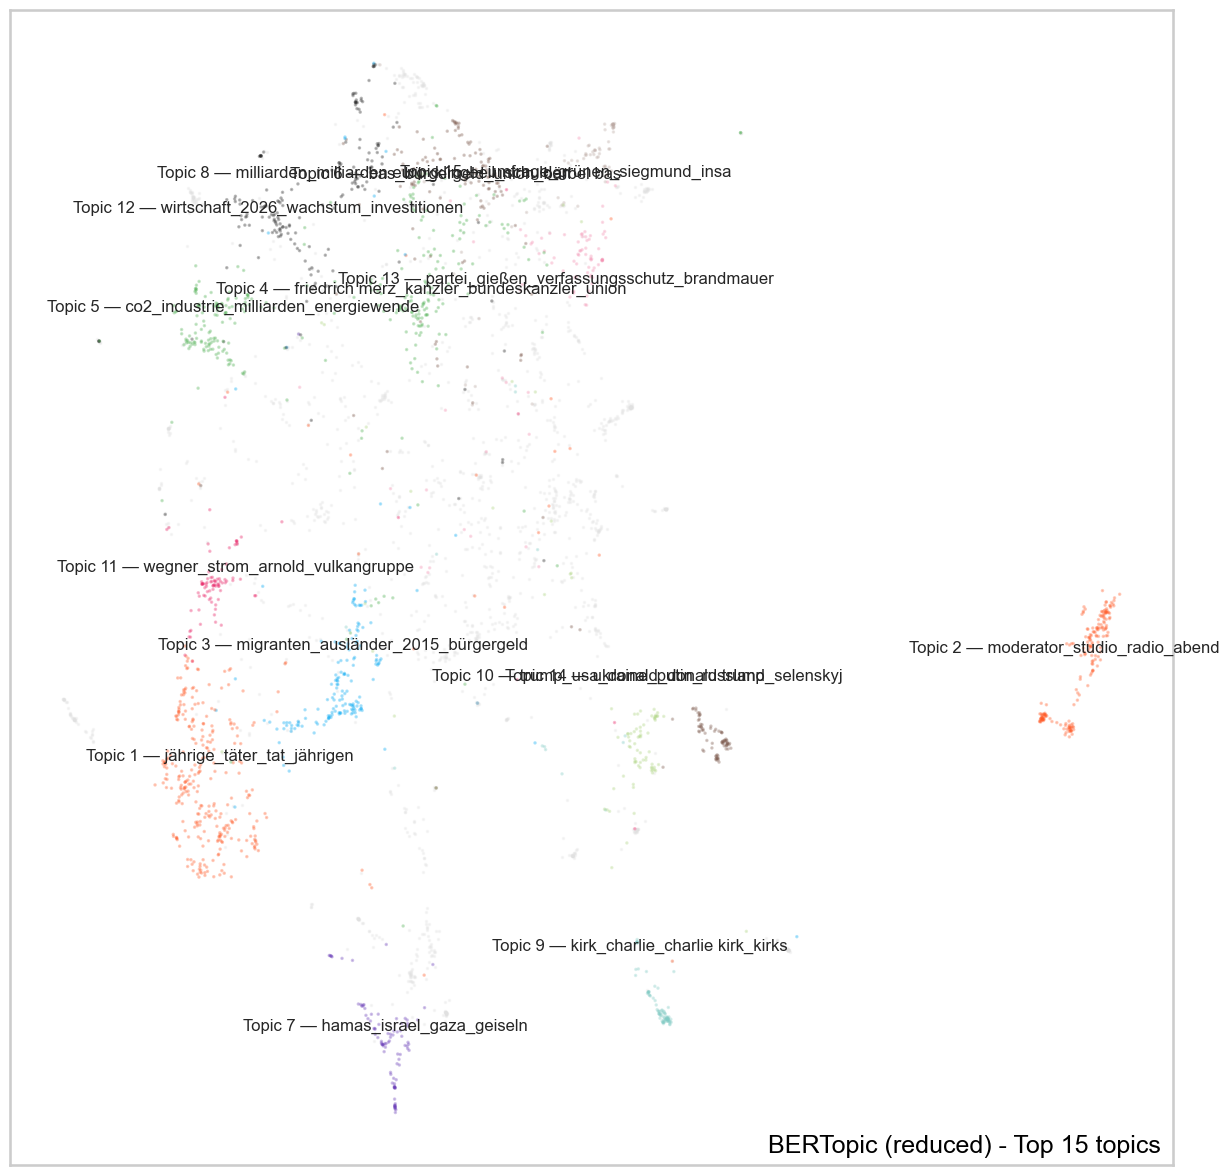

In [249]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from umap import UMAP

run_result = result_nius_reduced if "result_nius_reduced" in globals() else result_nius
topic_model_plot = run_result["topic_model"]
docs_plot = list(run_result["docs"])
topics_plot = list(run_result["topics"])
topic_info_plot = run_result["topic_info"].copy()
display_label_map = run_result["display_label_map"]

embeddings = topic_model_plot._extract_embeddings(docs_plot, method="document")
umap_model = UMAP(n_neighbors=10, n_components=2, min_dist=0.0, metric="cosine").fit(embeddings)
df_plot = pd.DataFrame(umap_model.embedding_, columns=["x", "y"])
df_plot["topic"] = topics_plot

top_n = 15
fontsize = 12

top_topic_ids = (
    topic_info_plot.loc[topic_info_plot["Topic"] != -1]
    .nsmallest(top_n, "DisplayTopic")["Topic"]
    .tolist()
)

to_plot = df_plot.copy()
to_plot.loc[~to_plot["topic"].isin(top_topic_ids), "topic"] = -1
outliers = to_plot.loc[to_plot["topic"] == -1]
non_outliers = to_plot.loc[to_plot["topic"] != -1]

cmap = matplotlib.colors.ListedColormap([
    "#FF5722", "#03A9F4", "#4CAF50", "#80CBC4", "#673AB7",
    "#795548", "#E91E63", "#212121", "#00BCD4", "#CDDC39",
    "#AED581", "#FFE082", "#BCAAA4", "#B39DDB", "#F48FB1",
])

fig, ax = plt.subplots(figsize=(15, 15))
ax.scatter(outliers["x"], outliers["y"], c="#E0E0E0", s=1, alpha=0.3)
ax.scatter(non_outliers["x"], non_outliers["y"], c=non_outliers["topic"], s=1, alpha=0.3, cmap=cmap)

centroids = non_outliers.groupby("topic", as_index=False)[["x", "y"]].mean()
for _, row in centroids.iterrows():
    topic = int(row["topic"])
    label = display_label_map.get(topic, f"Topic {topic}")
    ax.text(row["x"], row["y"] * 1.01, label, fontsize=fontsize, horizontalalignment="center")

ax.text(0.99, 0.01, f"BERTopic (reduced) - Top {top_n} topics",
        transform=ax.transAxes, horizontalalignment="right", color="black")
plt.xticks([], [])
plt.yticks([], [])
plt.show()


## Topics Over Time

Uses `result_nius_reduced` if you have already run the outlier-reduction cell; otherwise it falls back to `result_nius`.


6it [00:06,  1.01s/it]


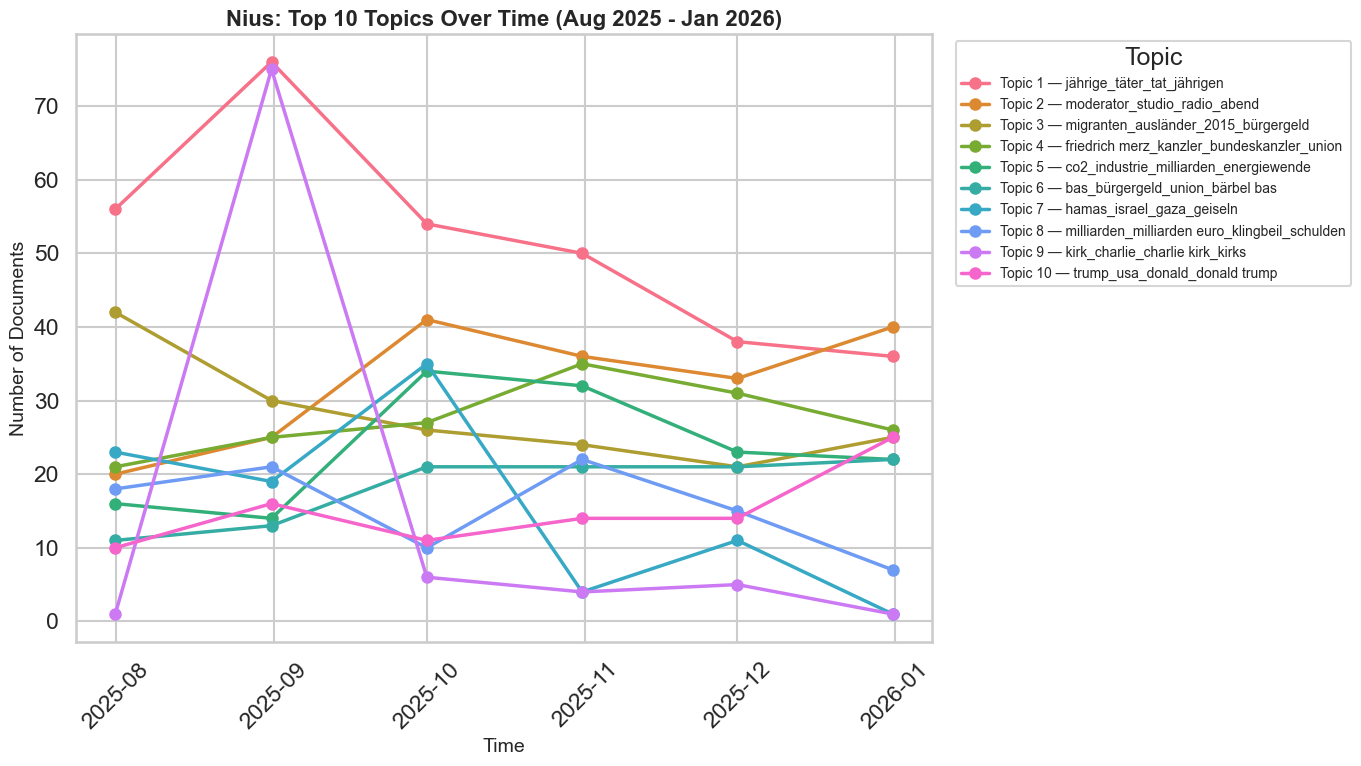

In [250]:
# Prepare data for topics over time using the final reduced model if it already exists.
# Re-run this cell after outlier reduction to pick up `result_nius_reduced`.
topic_time_result = result_nius_reduced if "result_nius_reduced" in globals() else result_nius

topic_info_time = topic_time_result["topic_info"].copy()
prepared_docs_time = topic_time_result["prepared_documents"]
date_col = "Date" if "Date" in prepared_docs_time.columns else "day"
prepared_dates = pd.to_datetime(prepared_docs_time[date_col], errors="coerce")
valid_time_mask = prepared_dates.notna().tolist()

docs_for_time = [doc for doc, ok in zip(topic_time_result["docs"], valid_time_mask) if ok]
topics_for_time = [topic for topic, ok in zip(topic_time_result["topics"], valid_time_mask) if ok]
timestamps_for_time = [ts for ts in prepared_dates.tolist() if pd.notna(ts)]

topics_over_time = topic_time_result["topic_model"].topics_over_time(
    docs_for_time,
    timestamps_for_time,
    topics=topics_for_time,
    nr_bins=6,
)

topic_info_non_outliers = topic_info_time.loc[topic_info_time["Topic"] != -1].copy()
if "DisplayTopic" in topic_info_non_outliers.columns:
    top_10_topics = topic_info_non_outliers.nsmallest(10, "DisplayTopic")["Topic"].tolist()
    label_map = dict(zip(topic_info_time["Topic"], topic_info_time["DisplayLabel"]))
else:
    top_10_topics = topic_info_non_outliers.nlargest(10, "Count")["Topic"].tolist()
    label_map = dict(zip(topic_info_time["Topic"], topic_info_time["Name"]))

topics_over_time_filtered = topics_over_time[topics_over_time["Topic"].isin(top_10_topics)]

fig, ax = plt.subplots(figsize=(14, 8))
sns.set_theme(style="whitegrid", context="talk")

palette = sns.color_palette("husl", n_colors=10)

for i, topic in enumerate(top_10_topics):
    topic_data = topics_over_time_filtered[topics_over_time_filtered["Topic"] == topic]
    label = label_map.get(topic, f"Topic {topic}")
    ax.plot(
        topic_data["Timestamp"],
        topic_data["Frequency"],
        marker="o",
        linewidth=2.5,
        markersize=8,
        color=palette[i],
        label=label,
    )

ax.set_xlabel("Time", fontsize=14)
ax.set_ylabel("Number of Documents", fontsize=14)
ax.set_title("Nius: Top 10 Topics Over Time (Aug 2025 - Jan 2026)", fontsize=16, fontweight="bold")
ax.legend(title="Topic", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=10)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


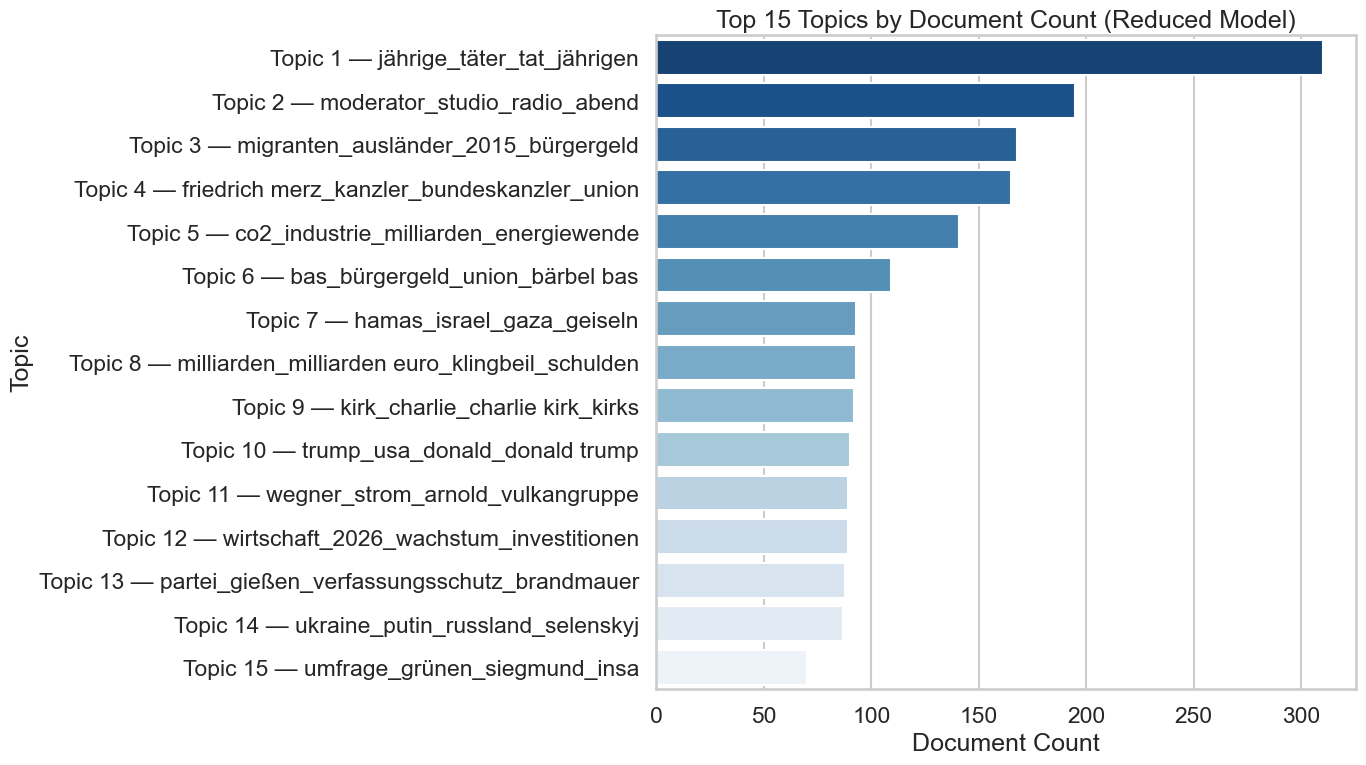

In [251]:
import seaborn as sns

# Ensure plotting libs exist in current kernel.
import matplotlib.pyplot as plt

# Re-run this cell after outlier reduction to visualize the final reduced model with unified topic numbering.
run_result = result_nius_reduced if "result_nius_reduced" in globals() else result_nius
topic_info_run = run_result["topic_info"].copy()

if "DisplayTopic" not in topic_info_run.columns:
    topic_info_run["OriginalTopic"] = topic_info_run["Topic"]
    topic_info_run["TopicNameClean"] = topic_info_run["Name"].str.replace(r"^\d+_", "", regex=True)
    ranked_topics = (
        topic_info_run.loc[topic_info_run["Topic"] != -1, ["Topic", "Count"]]
        .sort_values(["Count", "Topic"], ascending=[False, True])
        .reset_index(drop=True)
    )
    ranked_topics["DisplayTopic"] = range(1, len(ranked_topics) + 1)
    display_topic_map = dict(zip(ranked_topics["Topic"], ranked_topics["DisplayTopic"]))
    topic_info_run["DisplayTopic"] = topic_info_run["Topic"].map(display_topic_map).astype("Int64")
    topic_info_run["DisplayLabel"] = topic_info_run.apply(
        lambda row: "Outliers"
        if row["Topic"] == -1
        else f"Topic {int(row['DisplayTopic'])} — {row['TopicNameClean']}",
        axis=1,
    )

top15_topics = (
    topic_info_run.loc[topic_info_run["Topic"] != -1]
    .nsmallest(15, "DisplayTopic")
    .sort_values("DisplayTopic")
    .copy()
)

fig, ax = plt.subplots(figsize=(14, 8))
sns.barplot(
    data=top15_topics,
    x="Count",
    y="DisplayLabel",
    order=top15_topics["DisplayLabel"].tolist(),
    palette="Blues_r",
    ax=ax,
)

ax.set_title("Top 15 Topics by Document Count (Reduced Model)")
ax.set_xlabel("Document Count")
ax.set_ylabel("Topic")
plt.tight_layout()
plt.show()
